# K-Means Clustering — Personality Profiles in BFI-2 Data

## What is K-Means?

**K-Means** partitions n observations into **K clusters** by minimizing the **within-cluster sum of squares (WCSS)** — the total distance between each point and its cluster centroid.

The algorithm:
1. Randomly initialize K centroids
2. Assign each point to the nearest centroid
3. Recompute centroids as the mean of assigned points
4. Repeat steps 2–3 until centroids stop moving

### Why K-Means on personality data?
- Tests whether there are natural **personality types** in your sample
- Each cluster represents a group of people with similar Big Five + OCB + CWB profiles
- Cluster means reveal what characterizes each personality group
- Connects to a longstanding debate in psychology: **traits vs types**

### Pipeline
```
Big Five traits + OCB + CWB
        ↓
StandardScaler
        ↓
Elbow method + Silhouette score → choose K
        ↓
K-Means fit
        ↓
Interpret cluster profiles (centroid means)
        ↓
Compare clusters within demographic info (gender & age)

```

# 1. Import relevant packages, and preprocessing

K-Means clustering was applied to the standardized raw feature space comprising the Big Five personality traits, OCB, and CWB (7 variables). As a robustness check, clustering was also performed on the five-component PCA-reduced space (PC1–PC4, 87.2% variance retained); both approaches yielded the same optimal K, suggesting the results are stable across feature representations. The PCA-reduced solution is reported here for consistency with the broader unsupervised analysis pipeline, though conclusions are identical under either approach.

In [3]:
import json
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

import sys
import os

sys.path.append(os.path.abspath("../../src"))

from ml_models.k_means import KMeansAnalysis

print("✓ Imports complete")

# Find repo root
repo_root = Path.cwd().resolve()
while not (repo_root / "pca_coords.csv").exists():
    if repo_root == repo_root.parent:
        raise FileNotFoundError("Could not find pca_coords.csv — run pca.ipynb first")
    repo_root = repo_root.parent

pca_coords = pd.read_csv(repo_root / "pca_coords.csv")

# Clustering features: PC1–PC5 (87.2% variance)
pc_cols  = ["PC1", "PC2", "PC3", "PC4", "PC5"]
X_scaled = pca_coords[pc_cols].values

# Original features for cluster profiling
features = ["Extraversion", "Agreeableness", "Conscientiousness",
            "Neuroticism", "Openness", "OCB", "CWB"]
X_raw    = pca_coords[features]

print(f"  Clustering on: {pc_cols} (87.2% variance)")
print(f"  Samples: {X_scaled.shape[0]}")

✓ Imports complete
  Clustering on: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5'] (87.2% variance)
  Samples: 500


# 2. Choosing K

Both the elbow method and silhouette score were used to determine the optimal number of clusters. The elbow plot showed a smooth, gradual decline in WCSS without a sharp elbow, suggesting no strongly separated natural clusters. The silhouette score peaked at **K=2** (score = 0.237), indicating that a two-cluster solution provided the most internally cohesive and externally separated grouping. The low overall silhouette score (~0.24) is consistent with the PCA biplot finding that personality variation in this sample is largely continuous rather than 
discrete.

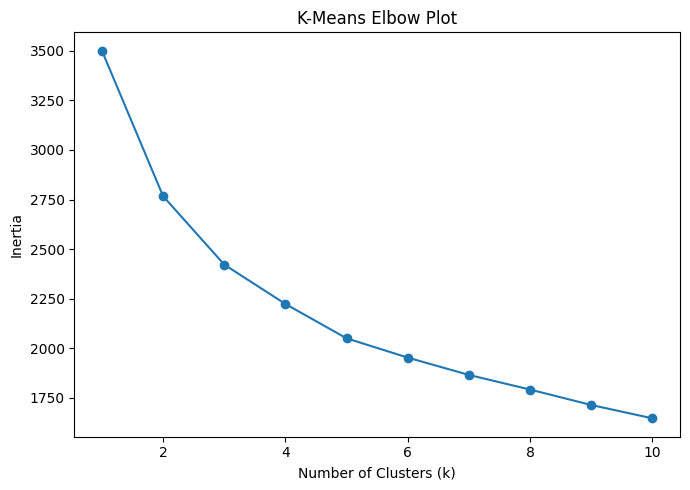

    k  silhouette_score
0   2          0.181522
1   3          0.161482
2   4          0.150106
3   5          0.148482
4   6          0.134224
5   7          0.131786
6   8          0.127530
7   9          0.129386
8  10          0.128619
Best k based on silhouette score: 2


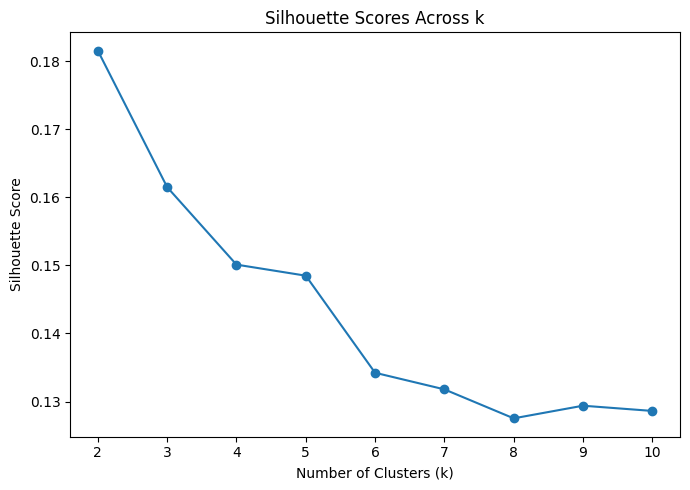

In [5]:
kmeans_model = KMeansAnalysis()
kmeans_model.elbow_plot(X_raw, max_k=10)
k_results, best_k_sil = kmeans_model.find_best_k(X_raw, max_k=10)

print(k_results)
print(f"Best k based on silhouette score: {best_k_sil}")

plt.figure(figsize=(7, 5))

plt.plot(
    k_results["k"],
    k_results["silhouette_score"],
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores Across k")

plt.tight_layout()
plt.show()

In [6]:
kmeans_final = KMeansAnalysis(n_clusters=best_k_sil)

kmeans_final.fit(X_raw)

cluster_labels = kmeans_final.labels_

In [7]:
df_clustered = X_raw.copy()

df_clustered["Cluster"] = cluster_labels

df_clustered.head()

,Extraversion,Agreeableness,Conscientiousness,Neuroticism,Openness,OCB,CWB,Cluster
0,2.416667,4.250000,3.083333,4.500000,4.750000,3.2,1.7,1
1,4.583333,4.250000,4.250000,1.583333,3.833333,2.7,1.1,0
2,3.916667,3.916667,2.500000,3.500000,4.083333,3.6,2.1,1
3,4.666667,4.500000,3.083333,2.583333,3.250000,2.8,1.5,0
4,2.916667,3.250000,3.583333,2.916667,3.416667,2.8,1.5,1


# 3. Clustering profiles

The two clusters differed meaningfully across all seven variables:

**Cluster 0 — "Adjusted/Prosocial" (n=222, 44%)**  
Cluster 0 participants showed substantially higher Conscientiousness (4.15), Agreeableness (4.08), and Extraversion (3.62), paired with markedly lower Neuroticism (2.36). OCB was higher (3.01) and CWB was lower (1.45), suggesting a well-adjusted, prosocial profile consistent with effective workplace behavior.

**Cluster 1 — "Stressed/Disengaged" (n=278, 56%)**  
Participants in Cluster 1 scored lower on Extraversion (2.82), Agreeableness (3.55), Conscientiousness (3.23), and Openness (3.63), while scoring higher on Neuroticism (3.29) and CWB (1.67) and lower on OCB (2.58). This profile is consistent with a stress-prone, less organizationally engaged personality type.

In [14]:
cluster_profile = kmeans_final.cluster_profiles(X_raw)
cluster_profile

,Extraversion,Agreeableness,Conscientiousness,Neuroticism,Openness,OCB,CWB
Cluster,,,,,,,
0,3.619,4.081,4.152,2.359,4.082,3.011,1.447
1,2.823,3.549,3.234,3.293,3.634,2.576,1.674


In [15]:
# Number of participants in each cluster
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()

print("Participants per Cluster:")
print(cluster_counts)

Participants per Cluster:
0    222
1    278
Name: count, dtype: int64


Cluster Profiles (mean scores, original scale):
         Extraversion  Agreeableness  Conscientiousness  Neuroticism  \
Cluster                                                                
0               3.619          4.081              4.152        2.359   
1               2.823          3.549              3.234        3.293   

         Openness    OCB    CWB  
Cluster                          
0           4.082  3.011  1.447  
1           3.634  2.576  1.674  


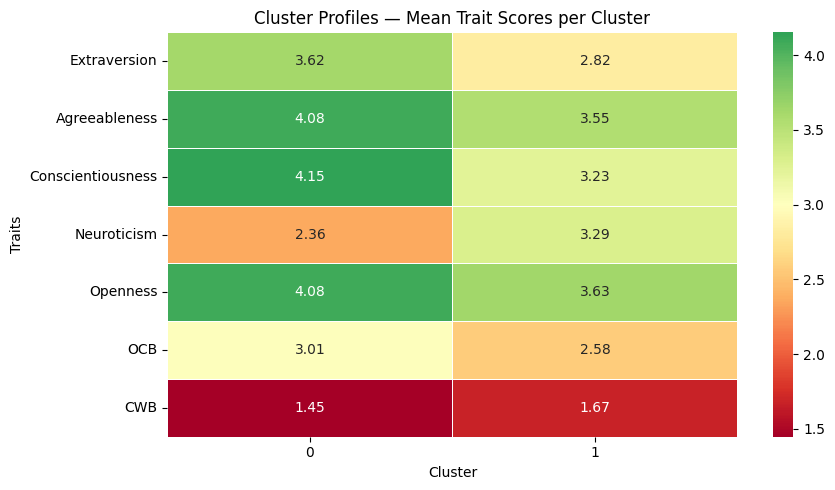

In [11]:
import seaborn as sns

# Add cluster labels to dataframe
df_clustered = X_raw.copy()
df_clustered["Cluster"] = cluster_labels

# Compute cluster profiles
cluster_profiles = (
    df_clustered
    .groupby("Cluster")[features]
    .mean()
    .round(3)
)

print("Cluster Profiles (mean scores, original scale):")
print(cluster_profiles)

# Heatmap of cluster profiles
fig, ax = plt.subplots(figsize=(9, 5))

sns.heatmap(
    cluster_profiles.T,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=3.0,
    linewidths=0.5,
    ax=ax
)

ax.set_title("Cluster Profiles — Mean Trait Scores per Cluster")
ax.set_xlabel("Cluster")
ax.set_ylabel("Traits")

plt.tight_layout()
plt.show()

# 4. Comparisons for certain demographic traits (age, gender)

Gender distribution per cluster (%):
Gender    Man  Non-binary  Prefer to self-describe, below:  Woman
Cluster                                                          
0        48.2         1.8                              0.0   50.0
1        41.0         1.8                              0.4   56.8


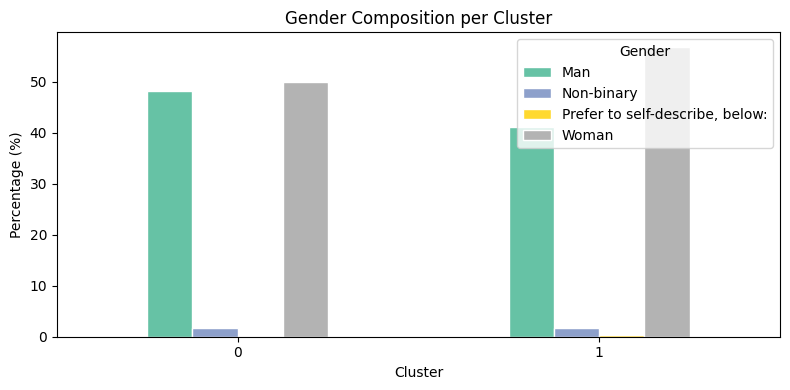

In [18]:
repo_root = Path.cwd().resolve()
while not (repo_root / "BFI_2_life_narative_metadata.json").exists():
    if repo_root == repo_root.parent:
        raise FileNotFoundError("Could not find BFI_2_life_narative_metadata.json")
    repo_root = repo_root.parent

# Load data
with open(repo_root / "BFI_2_life_narative_metadata.json", "r", encoding="utf-8") as f:
    metadata = json.load(f)

with open(repo_root / "BFI_2_life_narrative.json", "r", encoding="utf-8") as f:
    responses = json.load(f)

df = pd.DataFrame(responses)


# ── Load Gender and Age from original df ──
# (need original df since pca_coords.csv doesn't have demographics)
df_clustered["Gender"] = df["Gender"].iloc[:len(df_clustered)].reset_index(drop=True).values
df_clustered["Age"]    = df["Age"].iloc[:len(df_clustered)].reset_index(drop=True).values

# ── Gender distribution per cluster (categorical → bar chart) ──
gender_dist     = df_clustered.groupby(["Cluster", "Gender"]).size().unstack(fill_value=0)
gender_dist_pct = gender_dist.div(gender_dist.sum(axis=1), axis=0).round(3) * 100

print("Gender distribution per cluster (%):")
print(gender_dist_pct)

gender_dist_pct.plot(kind="bar", figsize=(8, 4), colormap="Set2", edgecolor="white")
plt.title("Gender Composition per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Age summary per cluster:
         count   mean    std   min   25%   50%   75%   max
Cluster                                                   
0        222.0  29.82  12.75  18.0  20.0  23.0  38.0  72.0
1        278.0  24.98   9.16  18.0  19.0  21.0  28.0  59.0


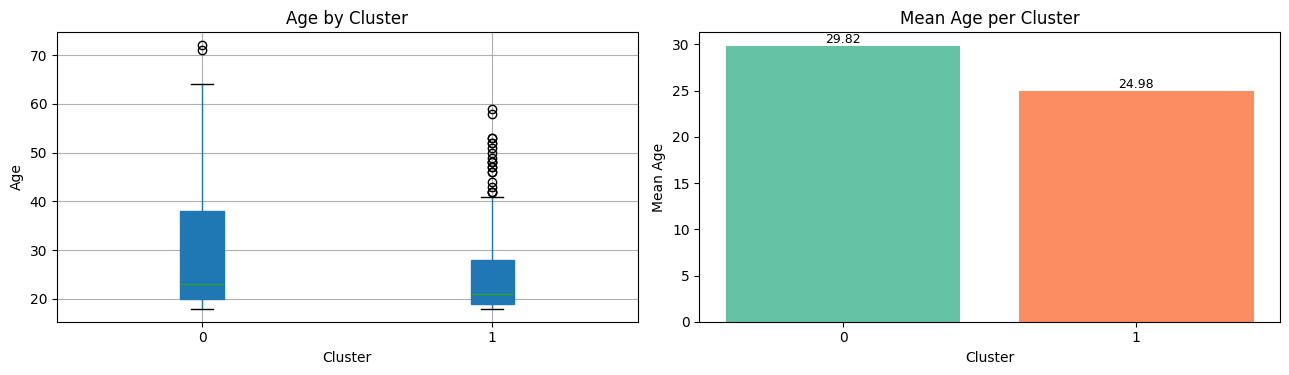

In [19]:
# ── Age distribution per cluster (continuous → boxplot) ──
print("\nAge summary per cluster:")
print(df_clustered.groupby("Cluster")["Age"].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Boxplot
df_clustered.boxplot(column="Age", by="Cluster", ax=axes[0],
                   patch_artist=True)
axes[0].set_title("Age Distribution per Cluster")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Age")
plt.sca(axes[0])
plt.title("Age by Cluster")
plt.suptitle("")   # removes default pandas suptitle

# Mean age bar chart
age_means = df_clustered.groupby("Cluster")["Age"].mean().round(2)
axes[1].bar(age_means.index.astype(str), age_means.values,
            color=sns.color_palette("Set2", len(age_means)))
axes[1].set_title("Mean Age per Cluster")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Mean Age")
for i, val in enumerate(age_means.values):
    axes[1].text(i, val + 0.3, str(val), ha="center", fontsize=9)

plt.tight_layout()
plt.show()


### Age Differences

Cluster 0 participants were notably older on average (M=29.8, SD=12.8) compared to Cluster 1 (M=25.0, SD=9.2). This age gap aligns with the **maturity principle** in personality development (Roberts et al., 2006), which posits that Conscientiousness and Agreeableness tend to increase while Neuroticism decreases across adulthood. The wider age range and standard deviation in Cluster 0 (18–72) compared to Cluster 1 (18–59) further suggests that the adjusted/prosocial profile becomes more common with age.

### Gender Differences

Cluster 1 had a higher proportion of women (56.8%) compared to Cluster 0 (50%), which was more gender-balanced. The higher Neuroticism in Cluster 0 is consistent with well-replicated findings of small but significant gender differences in Neuroticism (Costa et al., 2001). However, these differences are modest and should be interpreted cautiously given the sample composition and the correlational nature of the analysis.

### Limitations

- K=2 is statistically optimal but psychologically coarse — personality 
  research typically identifies 3–5 types
- The low silhouette score (0.18) indicates substantial overlap between clusters, confirming that personality variation is largely continuous in this sample
- K-Means assumes spherical clusters of equal variance, which may not hold for personality data
- Age and gender differences between clusters are descriptive and do not imply that personality types are caused by or reducible to demographics